# Construction Schedule Visualization

Strong+Medium adjacency 기반 precedence DAG (53-step critical chain) 에서 도출한 시공 로드맵을 3가지 형태로 시각화합니다.

1. **공정 간트 차트** — 존 별 시공 순서 + 클래스 구성 + 의존성
2. **공간 시공 순서** — 플랜트 평면도 위의 시공 진행 "파도"
3. **존 간 의존성 매트릭스** — 조율이 필요한 존 쌍 히트맵

모든 시각화는 `notebooks/figures/` 에 PNG 300dpi 로 저장됩니다.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import seaborn as sns
import networkx as nx
from pathlib import Path

from bimkg import config
from bimkg.analytics.metrics import build_physical_graph
from bimkg.analytics.zones import assign_louvain_zones, INSTALL_ORDER
from bimkg.analytics.precedence import build_precedence_dag, find_longest_chain

sns.set_theme(style="whitegrid", font_scale=1.0)
FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

gold = pd.read_parquet(config.ENRICHED_OBJECTS)
adj = pd.read_parquet(config.ENRICHED_ADJACENCY_SYM)

# Tier filter
def classify(row):
    if row["relation_type"] == "touch": return "Strong"
    if row["relation_type"] == "overlap" and row["overlap_volume_m3"] < 0.01: return "Medium"
    return "Weak"
adj["tier"] = adj.apply(classify, axis=1)
adj_sm = adj[adj["tier"].isin(["Strong", "Medium"])]

# Physical objects + zones (M3: use graph_participant flag)
G = build_physical_graph(gold, adj)
zone_map = assign_louvain_zones(G, resolution=3.0)
gold["zone_id"] = gold["object_id"].map(zone_map)
phys = gold[gold["graph_participant"] == True].copy()

# Precedence
dag = build_precedence_dag(gold, adj_sm, zone_col="zone_id")
chain = find_longest_chain(dag)
chain_set = set(chain)

# Zone dependency graph
zone_of = dict(zip(phys["object_id"], phys["zone_id"]))
zone_deps = {}
for u, v in dag.edges():
    zu, zv = zone_of.get(u), zone_of.get(v)
    if zu is not None and zv is not None and zu != zv:
        pair = (int(zu), int(zv))
        zone_deps[pair] = zone_deps.get(pair, 0) + 1

zone_dag = nx.DiGraph()
for (a, b), cnt in zone_deps.items():
    zone_dag.add_edge(a, b, weight=cnt)
while not nx.is_directed_acyclic_graph(zone_dag):
    cycle = nx.find_cycle(zone_dag)
    zone_dag.remove_edge(*cycle[-1][:2])
zone_order = list(nx.topological_sort(zone_dag))
for z in sorted(set(zone_map.values())):
    if z not in zone_order:
        zone_order.append(z)

# Zone stats
zone_stats = phys.dropna(subset=["zone_id"]).groupby("zone_id").agg(
    n_objects=("object_id", "count"),
    n_equipment=("refined_class", lambda s: (s == "Equipment").sum()),
    n_structure=("refined_class", lambda s: (s == "Structure").sum()),
    n_piping=("refined_class", lambda s: (s == "Piping").sum()),
    n_electrical=("refined_class", lambda s: (s == "Electrical").sum()),
    n_hvac=("refined_class", lambda s: (s == "HVAC").sum()),
    n_other=("refined_class", lambda s: (s == "Other").sum()),
    total_kg=("dry_weight_kg", "sum"),
    mean_x=("centroid_x", "mean"),
    mean_y=("centroid_y", "mean"),
    mean_z=("centroid_z", "mean"),
).reindex(zone_order).dropna(subset=["n_objects"])
zone_stats["install_rank"] = range(len(zone_stats))

print(f"Zones: {len(zone_stats)}, Critical chain: {len(chain)} steps (M3 clean graph)")
print(f"Zone dependency edges: {len(zone_deps)}")
print(f"Graph participants: {len(phys):,}")

Zones: 144, Critical chain: 44 steps (M3 clean graph)
Zone dependency edges: 108
Graph participants: 7,840


## 1. 공정 간트 차트

각 존이 하나의 행. 막대 길이 = 객체 수. 색상 = 클래스 구성 (stacked). 왼쪽에서 오른쪽으로 시공 순서.

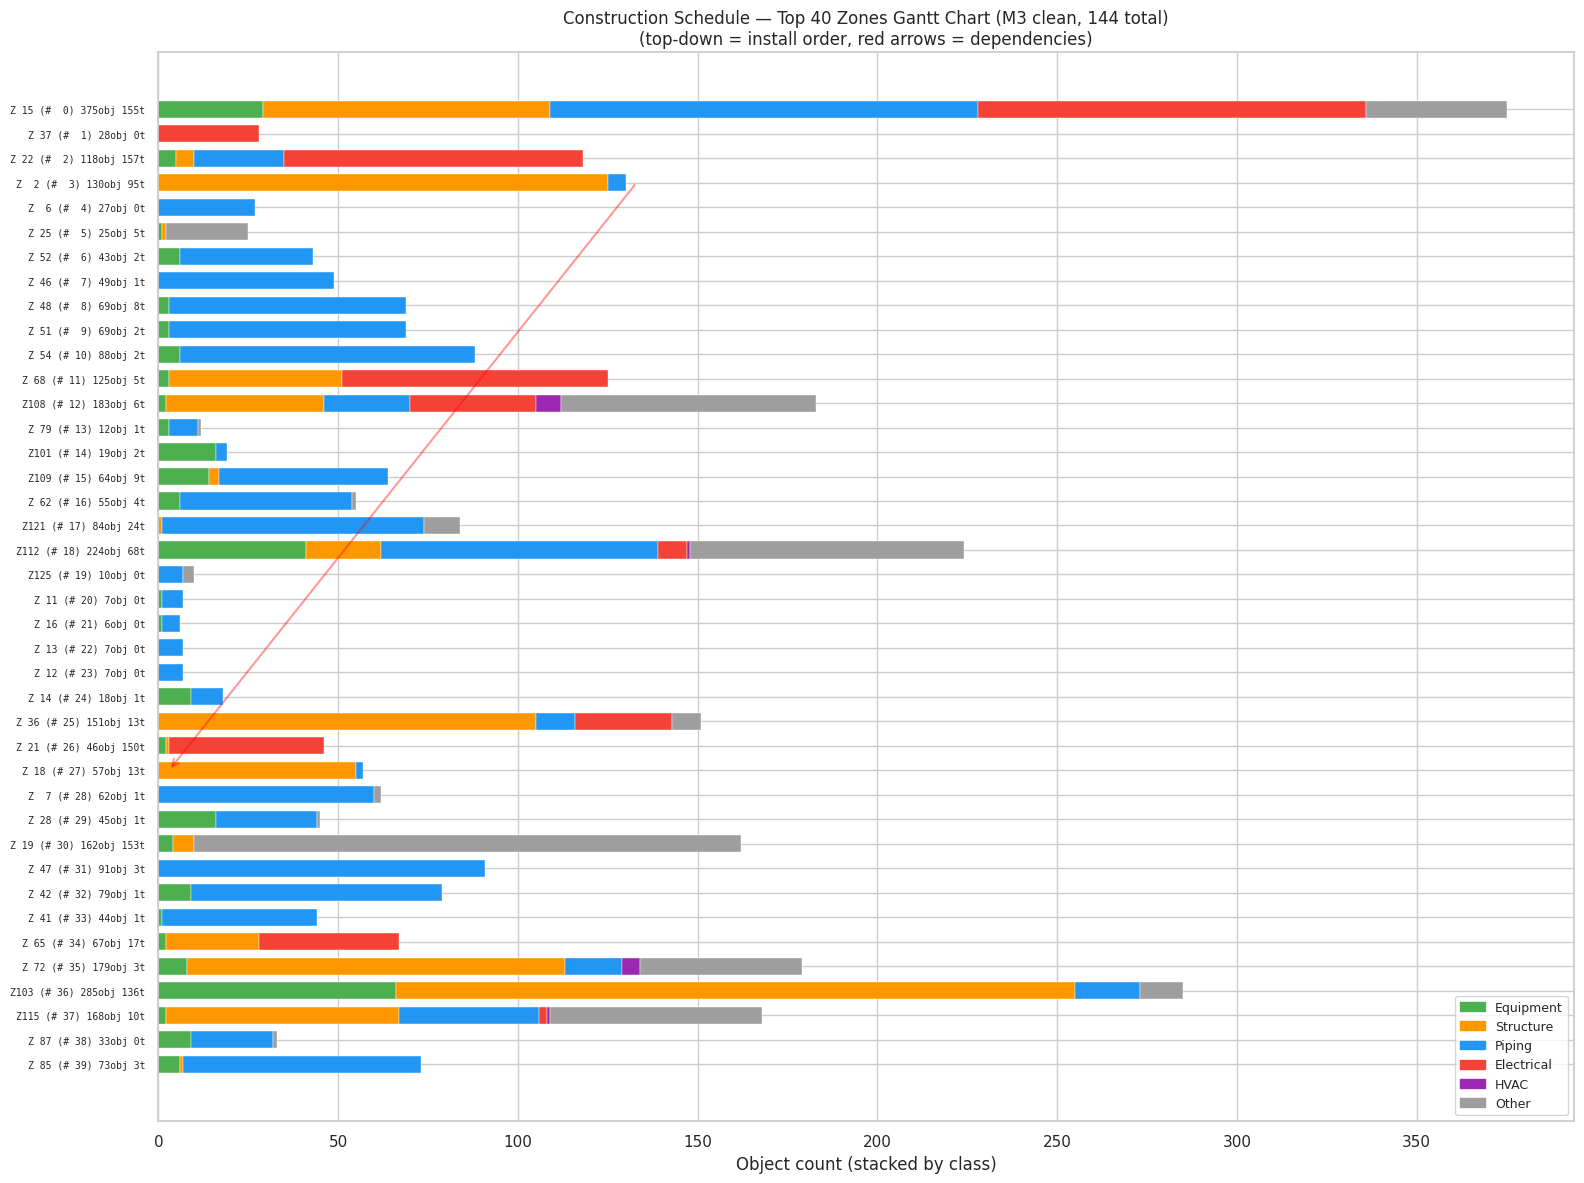

Saved: figures/04_s1_gantt_chart.png


In [2]:
class_colors = {
    "Equipment": "#4CAF50", "Structure": "#FF9800", "Piping": "#2196F3",
    "Electrical": "#F44336", "HVAC": "#9C27B0", "Other": "#9E9E9E"
}
class_cols = ["n_equipment", "n_structure", "n_piping", "n_electrical", "n_hvac", "n_other"]
class_labels = ["Equipment", "Structure", "Piping", "Electrical", "HVAC", "Other"]

# Top 40 zones by size for readable gantt
top_zones = zone_stats.head(40)

fig, ax = plt.subplots(figsize=(16, 12))

y_positions = range(len(top_zones))
labels = []

for y, (zone_id, row) in enumerate(top_zones.iterrows()):
    left = 0
    for col, cls in zip(class_cols, class_labels):
        width = row[col]
        if width > 0:
            ax.barh(y, width, left=left, height=0.7,
                    color=class_colors[cls], edgecolor="white", linewidth=0.3)
        left += width
    
    wt = row["total_kg"] / 1000 if pd.notna(row["total_kg"]) else 0
    labels.append(f"Z{int(zone_id):3d} (#{int(row['install_rank']):3d}) {row['n_objects']:.0f}obj {wt:.0f}t")

# Dependency arrows (top 10)
top_deps = sorted(zone_deps.items(), key=lambda x: -x[1])[:10]
rank_map = dict(zip(top_zones.index, range(len(top_zones))))
for (z1, z2), cnt in top_deps:
    if z1 in rank_map and z2 in rank_map:
        y1, y2 = rank_map[z1], rank_map[z2]
        x_start = top_zones.loc[z1, "n_objects"] + 3
        ax.annotate("", xy=(3, y2), xytext=(x_start, y1),
                    arrowprops=dict(arrowstyle="->", color="red", alpha=0.4, lw=1.5))

ax.set_yticks(y_positions)
ax.set_yticklabels(labels, fontsize=7, fontfamily="monospace")
ax.set_xlabel("Object count (stacked by class)")
ax.set_title(f"Construction Schedule — Top 40 Zones Gantt Chart (M3 clean, {len(zone_stats)} total)\n"
             "(top-down = install order, red arrows = dependencies)", fontsize=12)
ax.invert_yaxis()

patches = [mpatches.Patch(color=class_colors[c], label=c) for c in class_labels]
ax.legend(handles=patches, loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / "04_s1_gantt_chart.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES / '04_s1_gantt_chart.png'}")

## 2. 공간 시공 순서 — 플랜트 평면도 위의 시공 "파도"

각 객체의 위치 (X, Y) 에 시공 순서 (install rank) 를 색상 그라데이션으로 입힙니다. 파란색(초기) → 빨간색(후기). 시공이 플랜트의 어느 방향으로 진행되는지 한눈에 보입니다.

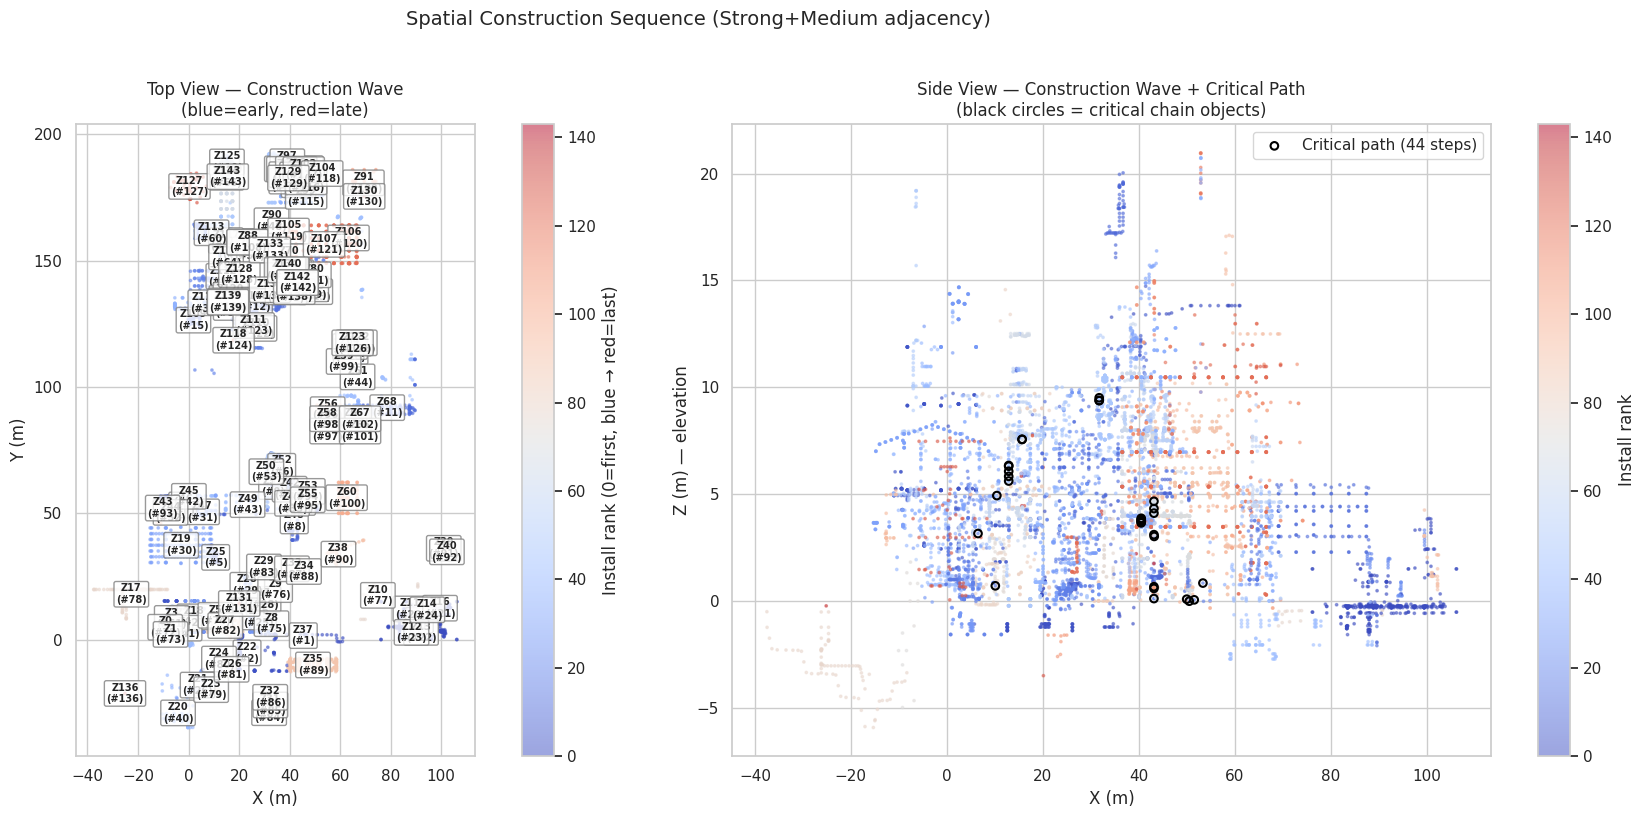

Saved: figures/04_s2_spatial_wave.png


In [3]:
# Map install_rank to each physical object via zone
rank_map_zone = dict(zip(zone_stats.index, zone_stats["install_rank"]))
phys["install_rank"] = phys["zone_id"].map(rank_map_zone)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left: top view colored by install rank
sc = axes[0].scatter(phys["centroid_x"], phys["centroid_y"],
                     c=phys["install_rank"], cmap="coolwarm",
                     s=3, alpha=0.5, vmin=0, vmax=len(zone_stats)-1)
plt.colorbar(sc, ax=axes[0], label="Install rank (0=first, blue → red=last)")

# Zone centroids with labels
for zone_id, row in zone_stats.iterrows():
    axes[0].annotate(f"Z{int(zone_id)}\n(#{int(row['install_rank'])})",
                     (row["mean_x"], row["mean_y"]),
                     fontsize=7, fontweight="bold", ha="center", va="center",
                     bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8))

axes[0].set_xlabel("X (m)")
axes[0].set_ylabel("Y (m)")
axes[0].set_title("Top View — Construction Wave\n(blue=early, red=late)")
axes[0].set_aspect("equal")

# Right: side view (X-Z) colored by install rank
sc2 = axes[1].scatter(phys["centroid_x"], phys["centroid_z"],
                      c=phys["install_rank"], cmap="coolwarm",
                      s=3, alpha=0.5, vmin=0, vmax=len(zone_stats)-1)
plt.colorbar(sc2, ax=axes[1], label="Install rank")

# Critical path highlighted
cp_objs = phys[phys["object_id"].isin(chain_set)]
axes[1].scatter(cp_objs["centroid_x"], cp_objs["centroid_z"],
                s=30, facecolors="none", edgecolors="black", linewidths=1.5,
                label=f"Critical path ({len(chain)} steps)", zorder=5)
axes[1].legend(loc="upper right")

axes[1].set_xlabel("X (m)")
axes[1].set_ylabel("Z (m) — elevation")
axes[1].set_title("Side View — Construction Wave + Critical Path\n(black circles = critical chain objects)")

plt.suptitle("Spatial Construction Sequence (Strong+Medium adjacency)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "04_s2_spatial_wave.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES / '04_s2_spatial_wave.png'}")

## 3. 존 간 의존성 매트릭스

히트맵: 행 = source 존 (먼저), 열 = target 존 (나중). 색이 진할수록 두 존 사이의 시공 의존성이 크고, 조율이 더 필요합니다.

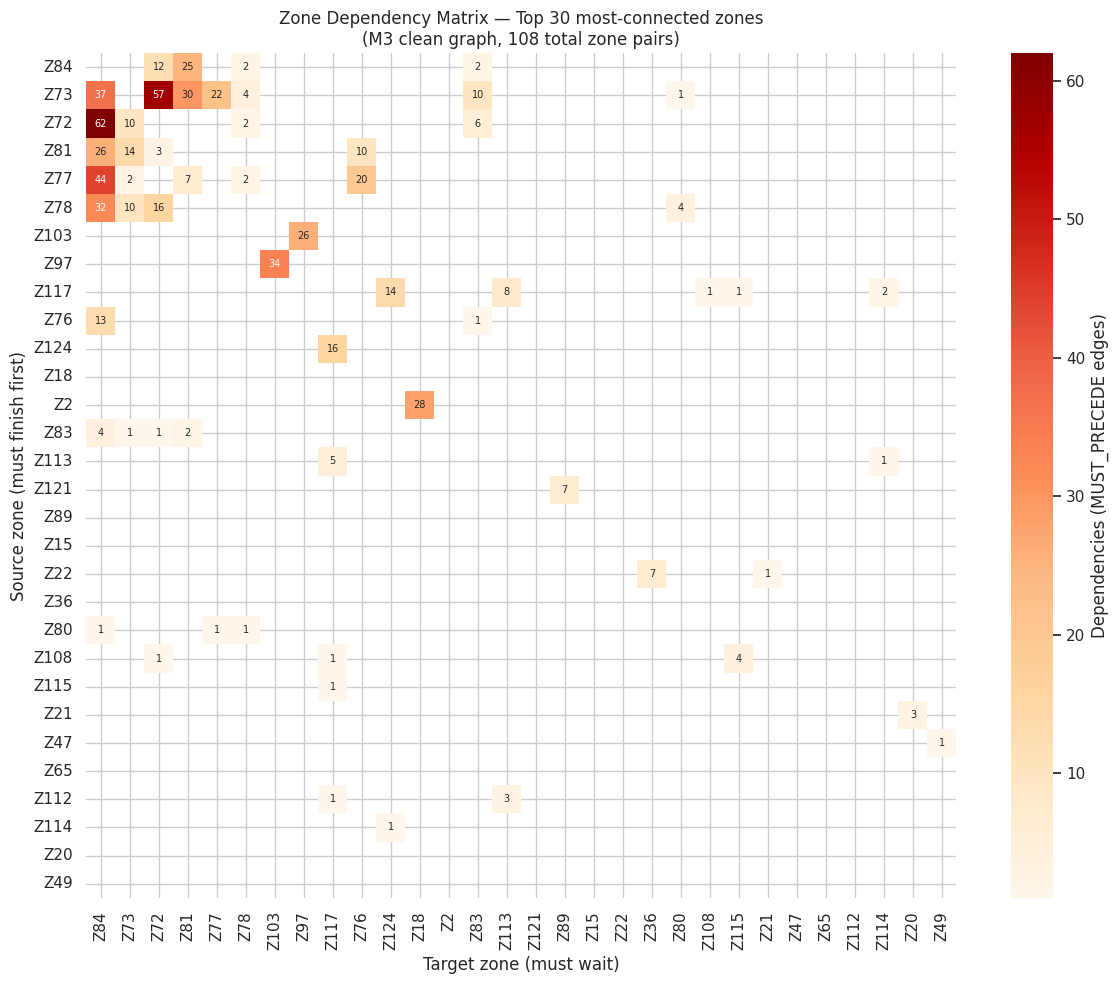

Top 10 zone dependencies:
  Zone  72 (rank 35) → Zone  84 (rank 55): 62 edges
  Zone  73 (rank 65) → Zone  72 (rank 35): 57 edges
  Zone  77 (rank 68) → Zone  84 (rank 55): 44 edges
  Zone  73 (rank 65) → Zone  84 (rank 55): 37 edges
  Zone  97 (rank 47) → Zone 103 (rank 36): 34 edges
  Zone  78 (rank 69) → Zone  84 (rank 55): 32 edges
  Zone  73 (rank 65) → Zone  81 (rank 63): 30 edges
  Zone   2 (rank 3) → Zone  18 (rank 27): 28 edges
  Zone  81 (rank 63) → Zone  84 (rank 55): 26 edges
  Zone 103 (rank 36) → Zone  97 (rank 47): 26 edges

Saved: figures/04_s3_dependency_matrix.png


In [4]:
# Build dependency matrix (top 30 zones with most dependencies)
dep_zone_ids = set()
for (z1, z2) in zone_deps:
    dep_zone_ids.add(z1)
    dep_zone_ids.add(z2)
top_dep_zones = sorted(dep_zone_ids, 
                        key=lambda z: sum(v for (a,b), v in zone_deps.items() if a == z or b == z),
                        reverse=True)[:30]

n = len(top_dep_zones)
zone_idx = {z: i for i, z in enumerate(top_dep_zones)}
matrix = np.zeros((n, n))
for (z1, z2), cnt in zone_deps.items():
    if z1 in zone_idx and z2 in zone_idx:
        matrix[zone_idx[z1], zone_idx[z2]] = cnt

fig, ax = plt.subplots(figsize=(12, 10))
mask = matrix == 0
sns.heatmap(matrix, mask=mask, annot=True, fmt=".0f", cmap="OrRd",
            xticklabels=[f"Z{z}" for z in top_dep_zones],
            yticklabels=[f"Z{z}" for z in top_dep_zones],
            ax=ax, cbar_kws={"label": "Dependencies (MUST_PRECEDE edges)"},
            annot_kws={"fontsize": 7})
ax.set_xlabel("Target zone (must wait)")
ax.set_ylabel("Source zone (must finish first)")
ax.set_title(f"Zone Dependency Matrix — Top {n} most-connected zones\n"
             f"(M3 clean graph, {len(zone_deps)} total zone pairs)")

plt.tight_layout()
plt.savefig(FIGURES / "04_s3_dependency_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

rank_map_zone = dict(zip(zone_stats.index, zone_stats["install_rank"]))
print("Top 10 zone dependencies:")
for (z1, z2), cnt in sorted(zone_deps.items(), key=lambda x: -x[1])[:10]:
    r1 = rank_map_zone.get(z1, "?")
    r2 = rank_map_zone.get(z2, "?")
    print(f"  Zone {z1:3d} (rank {r1}) → Zone {z2:3d} (rank {r2}): {cnt} edges")
print(f"\nSaved: {FIGURES / '04_s3_dependency_matrix.png'}")

## 4. Critical Path 상세 — 53단계 시각화

Critical chain 의 각 단계를 elevation (Z) 기준으로 그립니다. 색상 = 클래스, 화살표 = 선후 관계.

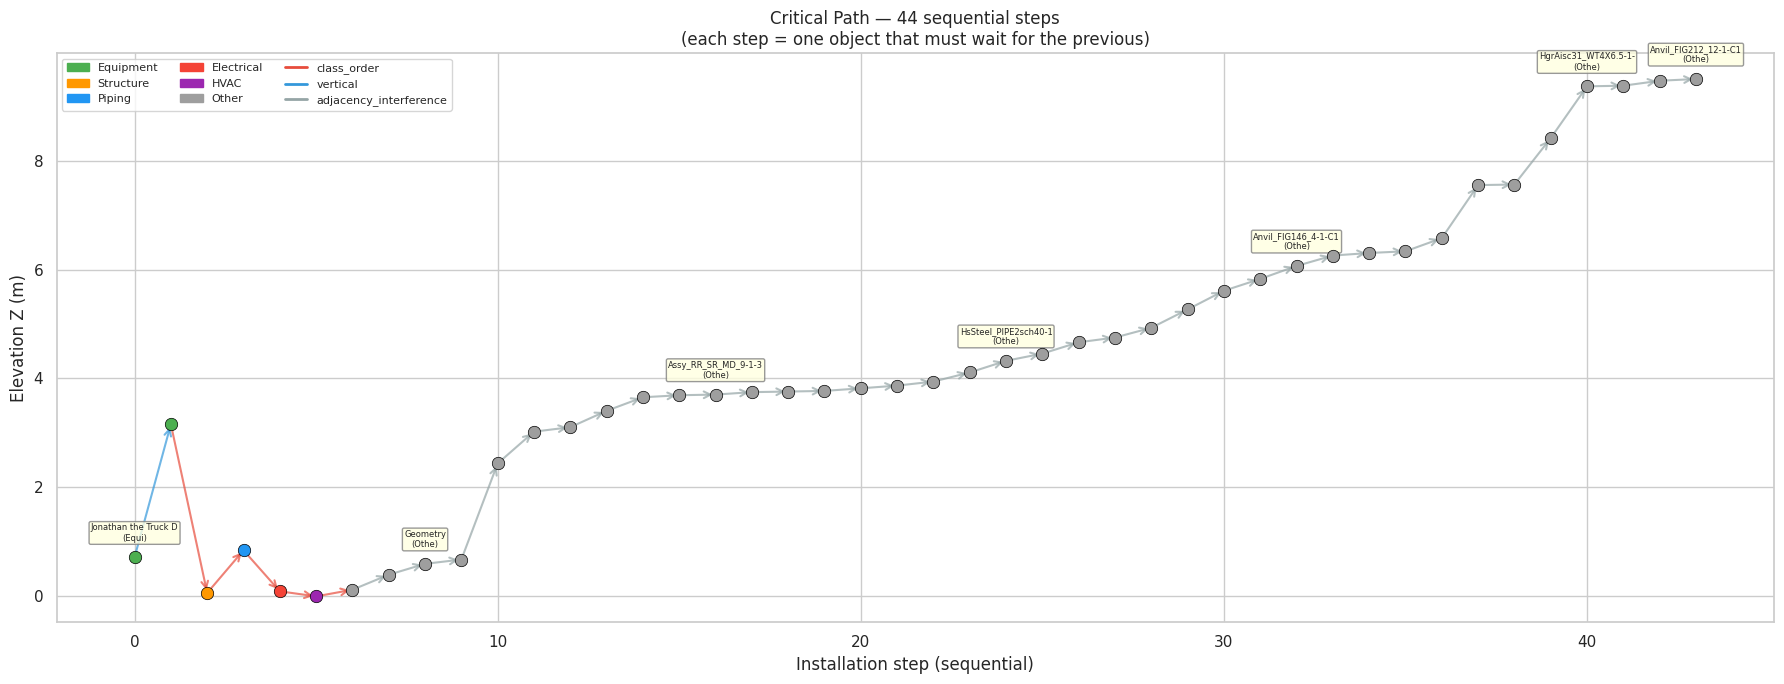

Saved: figures/04_s4_critical_path.png

Critical path class composition:
refined_class
Other         38
Equipment      2
Structure      1
Piping         1
Electrical     1
HVAC           1

Edge type composition:
edge_type
adjacency_interference    37
class_order                5
vertical                   1


In [5]:
from bimkg.analytics.precedence import critical_chain_summary

summary = critical_chain_summary(dag, gold)

fig, ax = plt.subplots(figsize=(18, 7))

# Plot steps as colored dots
for _, row in summary.iterrows():
    color = class_colors.get(row["refined_class"], "#999")
    z_val = row["centroid_z"] if pd.notna(row["centroid_z"]) else 0
    ax.scatter(row["step"], z_val, color=color, s=80, zorder=5, edgecolor="black", linewidth=0.5)

# Connect with arrows colored by edge_type
edge_type_colors = {"class_order": "#e74c3c", "vertical": "#3498db", "adjacency_interference": "#95a5a6"}
for i in range(1, len(summary)):
    prev = summary.iloc[i-1]
    curr = summary.iloc[i]
    z_prev = prev["centroid_z"] if pd.notna(prev["centroid_z"]) else 0
    z_curr = curr["centroid_z"] if pd.notna(curr["centroid_z"]) else 0
    ec = edge_type_colors.get(curr["edge_type"], "#999")
    ax.annotate("", xy=(curr["step"], z_curr), xytext=(prev["step"], z_prev),
                arrowprops=dict(arrowstyle="->", color=ec, lw=1.5, alpha=0.7))

# Labels for key steps (every 5th + first + last)
for _, row in summary.iterrows():
    if row["step"] % 8 == 0 or row["step"] == len(summary) - 1:
        name = str(row["display_name"])[:20] if pd.notna(row["display_name"]) else "?"
        z_val = row["centroid_z"] if pd.notna(row["centroid_z"]) else 0
        ax.annotate(f"{name}\n({row['refined_class'][:4]})",
                    (row["step"], z_val), fontsize=6,
                    textcoords="offset points", xytext=(0, 12), ha="center",
                    bbox=dict(boxstyle="round,pad=0.2", fc="lightyellow", ec="gray", alpha=0.8))

ax.set_xlabel("Installation step (sequential)")
ax.set_ylabel("Elevation Z (m)")
ax.set_title(f"Critical Path — {len(chain)} sequential steps\n"
             "(each step = one object that must wait for the previous)")

# Legends
class_patches = [mpatches.Patch(color=c, label=l) for l, c in class_colors.items()]
edge_patches = [plt.Line2D([0],[0], color=c, lw=2, label=l) for l, c in edge_type_colors.items()]
ax.legend(handles=class_patches + edge_patches, loc="upper left", fontsize=8, ncol=3)

plt.tight_layout()
plt.savefig(FIGURES / "04_s4_critical_path.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES / '04_s4_critical_path.png'}")

# Summary table
print(f"\nCritical path class composition:")
print(summary["refined_class"].value_counts().to_string())
print(f"\nEdge type composition:")
print(summary[summary["edge_type"] != ""]["edge_type"].value_counts().to_string())